# Klasifikasi buah apel,jeruk (segar dan busuk) : CNN From Scratch vs MobileNetV2

Notebook Google Colab ini memenuhi tahapan eksperimen berikut:

1. Mengunduh dataset Kaggle.
2. Memeriksa struktur, jumlah gambar, kelas, dan file rusak.
3. Membagi data secara **stratified 80% training, 10% validation, dan 10% testing**.
4. Melatih **CNN From Scratch** berbasis `Sequential`, `Conv2D`, dan `MaxPooling2D`.
5. Melatih **Transfer Learning MobileNetV2** dengan bobot `imagenet`.
6. Melakukan **feature extraction** dan **fine-tuning 20 layer terakhir**.
7. Menggunakan callback `EarlyStopping`, `ReduceLROnPlateau`, dan `ModelCheckpoint`.
8. Menampilkan grafik akurasi/loss, confusion matrix, classification report, serta analisis fit.
9. Membandingkan kedua model dan memilih model terbaik.
10. Mengekspor model ke **TensorFlow SavedModel**, **TensorFlow Lite**, dan **TensorFlow.js**.
11. Menguji inferensi TFLite menggunakan beberapa gambar dari testing set yang tidak digunakan saat training.

> **Saran runtime:** buka `Runtime → Change runtime type → T4 GPU` sebelum menjalankan seluruh sel.

## 1. Instalasi dan Import Library

`kagglehub` digunakan untuk mengunduh dataset. Library TensorFlow.js dipasang pada bagian ekspor agar tidak mengganggu versi TensorFlow selama training.

In [1]:
import os
import gc
import json
import math
import random
import shutil
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

import kagglehub

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow :", tf.__version__)
print("GPU       :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Konfigurasi Eksperimen

Nilai epoch dapat dinaikkan apabila akurasi validasi belum mencapai target. Ukuran citra `224 × 224` sesuai input standar MobileNetV2.

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset split
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# Image pipeline
IMG_HEIGHT = 224
IMG_WIDTH  = 224
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Training
SCRATCH_EPOCHS       = 30
TL_STAGE1_EPOCHS     = 30
TL_FINETUNE_EPOCHS   = 30
EXTRA_TUNING_EPOCHS  = 20
TARGET_ACCURACY      = 0.92
FINE_TUNE_LAYERS     = 20

# Aktifkan untuk melanjutkan training jika validation accuracy belum 85%
AUTO_TUNE_IF_NEEDED = True

# Output
OUTPUT_DIR = Path("/content/data_outputs")
MODEL_DIR  = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"
EXPORT_DIR = OUTPUT_DIR / "exports"

for directory in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR, EXPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/data_outputs


## 3. Download Dataset Kaggle

### Mengunduh Dataset

Mengunduh dataset . Setelah diunduh, sistem akan secara otomatis mencari file ZIP di dalamnya untuk diekstraksi.

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="t1N9MMpfxffNjqLYbK9z")
project = rf.workspace("gzaa").project("data_set_a_o_l-168v2")
version = project.version(1)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DATA_SET_A_O_L-1 in folder:: 100%|██████████| 10937/10937 [00:01<00:00, 10580.74it/s]


In [4]:
from pathlib import Path

# DATASET_PATH sudah diatur oleh unduhan kagglehub di sel sebelumnya (9334b01b)
# Variabel 'path' berisi lokasi dataset yang sudah diekstrak
DATASET_PATH = Path(dataset.location)

print("Path to dataset files:", DATASET_PATH)
print("Dataset tersedia:", DATASET_PATH.exists())

Path to dataset files: /content/DATA_SET_A_O_L-1
Dataset tersedia: True


## 4. Pemeriksaan Struktur Dataset

Fungsi berikut mencari semua gambar secara rekursif. Label ditentukan dengan aturan:

- Struktur `train/nama_kelas/gambar.jpg` → label adalah `nama_kelas`.
- Struktur `validation/nama_kelas/gambar.jpg` → label adalah `nama_kelas`.
- Struktur `dataset/nama_kelas/gambar.jpg` → label adalah nama folder induk gambar.

Split bawaan dataset tidak digunakan sebagai split akhir. Semua data dikumpulkan lalu dibagi ulang secara stratified 80:10:10 untuk menjamin proporsi yang konsisten.

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

SPLIT_ALIASES = {
    "train": "train",
    "training": "train",
    "val": "validation",
    "valid": "validation",
    "validation": "validation",
    "test": "test",
    "testing": "test",
}

def infer_label_and_original_split(image_path: Path, root: Path):
    relative_parts = list(image_path.relative_to(root).parts)
    lower_parts = [part.lower() for part in relative_parts]

    # Cari pola split/kelas/file
    for index, part in enumerate(lower_parts[:-1]):
        if part in SPLIT_ALIASES and index + 1 < len(relative_parts) - 1:
            label = relative_parts[index + 1]
            return label, SPLIT_ALIASES[part]

    # Default: nama folder induk gambar
    return image_path.parent.name, "raw"

image_paths = sorted([
    file_path
    for file_path in DATASET_PATH.rglob("*")
    if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
])

if not image_paths:
    raise FileNotFoundError(
        f"Tidak ditemukan file gambar di {DATASET_PATH}. "
        "Periksa hasil download atau struktur dataset."
    )

records = []
for image_path in image_paths:
    label, original_split = infer_label_and_original_split(image_path, DATASET_PATH)
    records.append({
        "filepath": str(image_path),
        "label": str(label).strip(),
        "original_split": original_split,
    })

df = pd.DataFrame(records)
print(f"Jumlah file gambar awal: {len(df):,}")
print(f"Jumlah label terdeteksi : {df['label'].nunique()}")
display(df.head())

Jumlah file gambar awal: 10,935
Jumlah label terdeteksi : 6


,filepath,label,original_split
0,/content/DATA_SET_A_O_L-1/test/freshapples/Scr...,freshapples,test
1,/content/DATA_SET_A_O_L-1/test/freshapples/Scr...,freshapples,test
2,/content/DATA_SET_A_O_L-1/test/freshapples/Scr...,freshapples,test
3,/content/DATA_SET_A_O_L-1/test/freshapples/Scr...,freshapples,test
4,/content/DATA_SET_A_O_L-1/test/freshapples/Scr...,freshapples,test


In [6]:
# Tampilkan struktur direktori secara ringkas
def print_tree(root: Path, max_depth=3, max_items_per_dir=8):
    root = Path(root)
    print(root.name + "/")

    def walk(directory, prefix="", depth=0):
        if depth >= max_depth:
            return

        try:
            items = sorted(directory.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
        except PermissionError:
            return

        shown = items[:max_items_per_dir]
        for i, item in enumerate(shown):
            connector = "└── " if i == len(shown) - 1 else "├── "
            print(prefix + connector + item.name + ("/" if item.is_dir() else ""))
            if item.is_dir():
                extension = "    " if i == len(shown) - 1 else "│   "
                walk(item, prefix + extension, depth + 1)

        if len(items) > max_items_per_dir:
            print(prefix + f"└── ... ({len(items) - max_items_per_dir} item lain)")

    walk(root)

print_tree(DATASET_PATH)

DATA_SET_A_O_L-1/
├── test/
│   ├── freshapples/
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-4-59-44-PM_png.rf.7e05b64f13e6df6e2d0c12c46a1739af.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-00-18-PM_png.rf.5cc72cab5ebbcec82fb3d71d59751943.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-06-28-PM_png.rf.dd286328ab97a71072cc3f67db84aecf.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-06-33-PM_png.rf.f14dc70eafbb0844b3dd592293b80794.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-07-05-PM_png.rf.6aff5528bd1827f2e75af902c0e381be.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-08-58-PM_png.rf.e16e02f463f5c7e3560ddbb28eed196a.jpg
│   │   ├── rotated_by_15_Screen-Shot-2018-06-08-at-5-09-31-PM_png.rf.7ffe0acbe7b8cd639e9edb96e3429856.jpg
│   │   └── rotated_by_15_Screen-Shot-2018-06-08-at-5-09-40-PM_png.rf.58ba7e96acff7c0f76a6f7e8a0c77970.jpg
│   │   └── ... (199 item lain)
│   ├── freshlemons/
│   │   ├── good_quality_1019_jpg.rf.00ffc

## 5. Validasi File Gambar dan Distribusi Kelas

File gambar yang tidak dapat dibaca akan dikeluarkan. Pemeriksaan ini mencegah proses training berhenti karena file rusak.

In [7]:
def verify_image(filepath):
    try:
        with Image.open(filepath) as image:
            image.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

print("Memeriksa integritas gambar...")

with ThreadPoolExecutor(max_workers=min(32, (os.cpu_count() or 4) * 2)) as executor:
    valid_flags = list(executor.map(verify_image, df["filepath"].tolist()))

df["is_valid"] = valid_flags

invalid_df = df[~df["is_valid"]].copy()
df = df[df["is_valid"]].drop(columns="is_valid").reset_index(drop=True)

print(f"Gambar valid : {len(df):,}")
print(f"Gambar rusak : {len(invalid_df):,}")

if len(invalid_df) > 0:
    display(invalid_df.head())
    invalid_df.to_csv(RESULT_DIR / "invalid_images.csv", index=False)

Memeriksa integritas gambar...
Gambar valid : 10,935
Gambar rusak : 0


In [8]:
# Hapus label kosong dan kelas yang terlalu kecil untuk stratified split
df = df[df["label"].astype(str).str.len() > 0].copy()

MIN_IMAGES_PER_CLASS = 20
class_counts = df["label"].value_counts()
small_classes = class_counts[class_counts < MIN_IMAGES_PER_CLASS]

if len(small_classes) > 0:
    print("Kelas berikut dikeluarkan karena jumlah gambar kurang dari",
          MIN_IMAGES_PER_CLASS)
    display(small_classes.rename("jumlah_gambar").to_frame())
    df = df[~df["label"].isin(small_classes.index)].reset_index(drop=True)

class_counts = df["label"].value_counts().sort_index()
num_classes = len(class_counts)
total_images = len(df)

print(f"Total gambar siap pakai : {total_images:,}")
print(f"Jumlah kelas            : {num_classes}")

if num_classes <3:
    raise ValueError(
        f"Hanya terdeteksi {num_classes} kelas. Tugas mewajibkan minimal 4 kelas. "
        "Periksa struktur folder atau fungsi inferensi label."
    )

if total_images < 8_000:
    print(
        f"⚠️ PERINGATAN: total gambar hanya {total_images:,}, "
        "sedangkan ketentuan tugas minimal 8.000 gambar."
    )
else:
    print("✅ Ketentuan minimal 8.000 gambar terpenuhi.")

display(class_counts.rename("jumlah_gambar").to_frame())

Total gambar siap pakai : 10,935
Jumlah kelas            : 6
✅ Ketentuan minimal 8.000 gambar terpenuhi.


,jumlah_gambar
label,
freshapples,2088
freshlemons,1125
freshoranges,1830
rottenapples,2943
rottenlemons,951
rottenoranges,1998


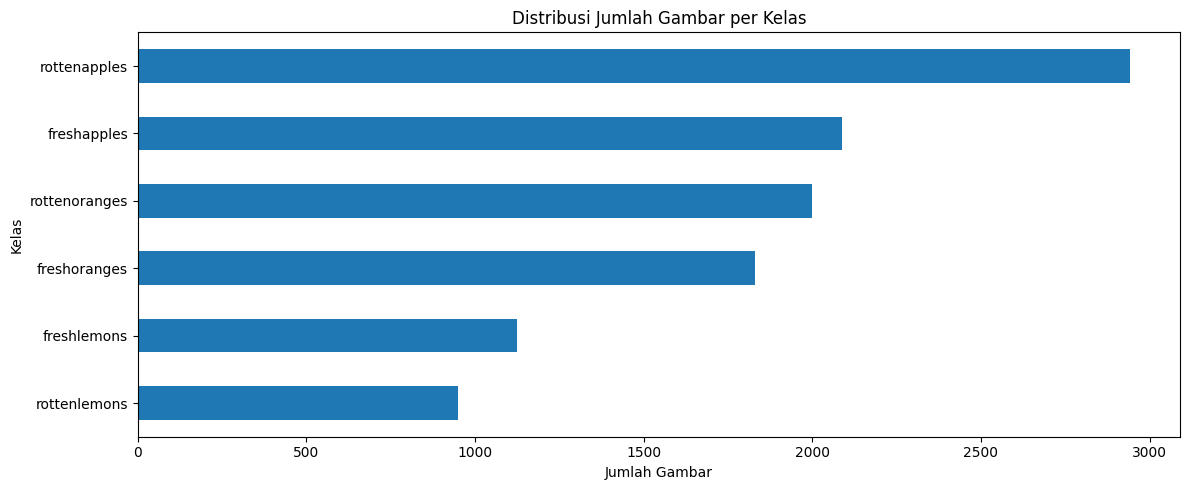

In [9]:
plt.figure(figsize=(12, max(5, num_classes * 0.35)))
class_counts.sort_values().plot(kind="barh")
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Jumlah Gambar")
plt.ylabel("Kelas")
plt.tight_layout()
plt.savefig(RESULT_DIR / "distribusi_kelas.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Stratified Split 80:10:10

`stratify` menjaga proporsi setiap kelas tetap hampir sama pada training, validation, dan testing.

In [10]:
class_names = sorted(df["label"].unique().tolist())
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

df["label_id"] = df["label"].map(class_to_index).astype("int32")

# 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=df["label"],
)

# Temporary 20% dibagi menjadi 10% validation dan 10% testing
relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Training   : {len(train_df):,} ({len(train_df)/len(df):.2%})")
print(f"Validation : {len(val_df):,} ({len(val_df)/len(df):.2%})")
print(f"Testing    : {len(test_df):,} ({len(test_df)/len(df):.2%})")

assert set(train_df["filepath"]).isdisjoint(set(val_df["filepath"]))
assert set(train_df["filepath"]).isdisjoint(set(test_df["filepath"]))
assert set(val_df["filepath"]).isdisjoint(set(test_df["filepath"]))

train_df.assign(split="train").to_csv(RESULT_DIR / "train_split.csv", index=False)
val_df.assign(split="validation").to_csv(RESULT_DIR / "validation_split.csv", index=False)
test_df.assign(split="test").to_csv(RESULT_DIR / "test_split.csv", index=False)

with open(RESULT_DIR / "class_names.json", "w", encoding="utf-8") as file:
    json.dump(class_names, file, ensure_ascii=False, indent=2)

split_distribution = pd.concat([
    train_df["label"].value_counts().rename("train"),
    val_df["label"].value_counts().rename("validation"),
    test_df["label"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int).sort_index()

display(split_distribution)

Training   : 8,748 (80.00%)
Validation : 1,093 (10.00%)
Testing    : 1,094 (10.00%)


,train,validation,test
label,,,
freshapples,1670,209,209
freshlemons,900,112,113
freshoranges,1464,183,183
rottenapples,2355,294,294
rottenlemons,761,95,95
rottenoranges,1598,200,200


## 7. Membuat Pipeline `tf.data`

Resize dilakukan melalui kode, sehingga resolusi gambar asli boleh tidak seragam. Data augmentation ditempatkan di dalam model dan hanya aktif saat training.

In [11]:
def load_and_resize_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear",
        antialias=True
    )
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].astype(str).values,
            dataframe["label_id"].astype("int32").values,
        )
    )

    options = tf.data.Options()
    options.experimental_deterministic = not training
    dataset = dataset.with_options(options)

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10_000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE,
    )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

print("Train element spec:", train_ds.element_spec)

Train element spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [12]:
# Bobot kelas membantu apabila distribusi dataset tidak seimbang
classes_array = np.array(sorted(train_df["label_id"].unique()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=train_df["label_id"].values,
)

class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes_array, weights)
}

print("Class weight:")
for class_id, weight in class_weight.items():
    print(f"{class_names[class_id]:25s}: {weight:.4f}")

Class weight:
freshapples              : 0.8731
freshlemons              : 1.6200
freshoranges             : 0.9959
rottenapples             : 0.6191
rottenlemons             : 1.9159
rottenoranges            : 0.9124


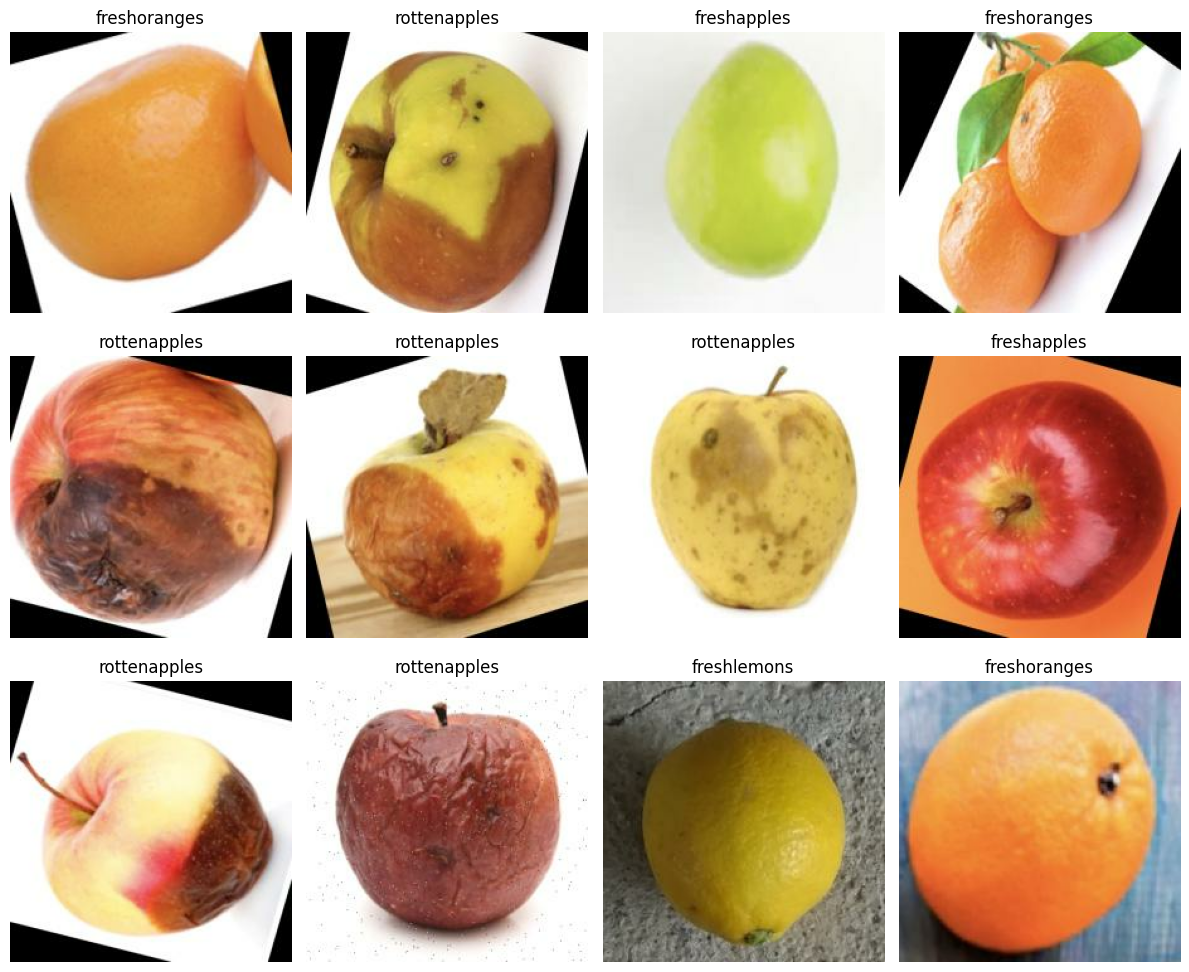

In [13]:
# Visualisasi sampel training
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 10))
for index in range(min(12, len(images))):
    plt.subplot(3, 4, index + 1)
    plt.imshow(tf.cast(images[index], tf.uint8))
    plt.title(class_names[int(labels[index])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Data Augmentation

Augmentasi meningkatkan variasi data training dan membantu mengurangi overfitting. Transformasi dibuat moderat agar karakter objek sampah tidak berubah secara berlebihan.

In [14]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.18),
        layers.RandomZoom(0.20),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomContrast(0.20),
        layers.RandomBrightness(0.19),
        layers.RandomContrast(0.15)
    ],
    name="data_augmentation",
)

## 9. Fungsi Callback

- **EarlyStopping:** menghentikan training ketika `val_loss` tidak membaik dan mengembalikan bobot terbaik.
- **ReduceLROnPlateau:** menurunkan learning rate ketika model stagnan.
- **ModelCheckpoint:** menyimpan model dengan `val_accuracy` terbaik.

In [15]:
def create_callbacks(model_name):
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
    ]

    return callbacks, checkpoint_path

# Model 1 — CNN From Scratch

Arsitektur dibuat menggunakan `Sequential`, beberapa blok `Conv2D + BatchNormalization + MaxPooling2D`, `GlobalAveragePooling2D`, `Dense`, dan `Dropout`.

In [16]:
tf.keras.backend.clear_session()

model_scratch = keras.Sequential(
    [
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),


        layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),


        layers.Conv2D(384, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax", dtype="float32"),
    ],
    name="cnn_from_scratch",
)

model_scratch.compile(
    optimizer=keras.optimizers.Adamax(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

model_scratch.summary()

Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 384)    │       884,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,377,254 (5.25 MB)

 Trainable params: 1,375,014 (5.25 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [17]:
scratch_callbacks, scratch_checkpoint = create_callbacks("cnn_scratch")

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=SCRATCH_EPOCHS,
    callbacks=scratch_callbacks,
    class_weight=class_weight,
)

Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6557 - loss: 0.9683
Epoch 1: val_accuracy improved from None to 0.09515, saving model to /content/data_outputs/models/cnn_scratch_best.keras

Epoch 1: finished saving model to /content/data_outputs/models/cnn_scratch_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.7441 - loss: 0.6871 - val_accuracy: 0.0952 - val_loss: 5.3213 - learning_rate: 0.0010
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8189 - loss: 0.4762
Epoch 2: val_accuracy improved from 0.09515 to 0.58371, saving model to /content/data_outputs/models/cnn_scratch_best.keras

Epoch 2: finished saving model to /content/data_outputs/models/cnn_scratch_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 74s 145ms/step - accuracy: 0.8214 - loss: 0.4602 - val_accuracy: 0.5837 - val_loss: 1.1737 - learning_rate: 0.0010
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8482 - loss: 0.3793
Epoch 3: val_accuracy improve

### Tuning Otomatis CNN

Testing set **tidak digunakan** untuk mengambil keputusan tuning. Apabila akurasi validasi terbaik belum 85%, training dilanjutkan menggunakan learning rate yang lebih kecil.

In [18]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

extra_history_scratch = None
best_scratch_val = max(history_scratch.history.get("val_accuracy", [0]))

if AUTO_TUNE_IF_NEEDED and best_scratch_val < TARGET_ACCURACY:
    print(
        f"Validation accuracy terbaik CNN baru {best_scratch_val:.2%}. "
        "Melanjutkan tuning dengan learning rate 1e-4..."
    )

    model_scratch.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    scratch_tune_callbacks, _ = create_callbacks("cnn_scratch_tuned")

    extra_history_scratch = model_scratch.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EXTRA_TUNING_EPOCHS,
        callbacks=scratch_tune_callbacks,
        class_weight=class_weight,
    )
else:
    print(f"Validation accuracy CNN terbaik: {best_scratch_val:.2%}")

scratch_history_all = merge_histories(history_scratch, extra_history_scratch)

Validation accuracy CNN terbaik: 98.90%


## 10. Fungsi Visualisasi dan Evaluasi

In [19]:
def plot_training_history(history_dict, model_name, save_prefix):
    epochs = range(1, len(history_dict["accuracy"]) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history_dict["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history_dict["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"{save_prefix}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history_dict["loss"], label="Training Loss")
    plt.plot(epochs, history_dict["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"{save_prefix}_loss.png", dpi=150)
    plt.show()

def collect_predictions(model, dataset):
    y_true = []
    y_probability = []

    for batch_images, batch_labels in dataset:
        probabilities = model.predict(batch_images, verbose=0)
        y_probability.append(probabilities)
        y_true.append(batch_labels.numpy())

    y_true = np.concatenate(y_true)
    y_probability = np.concatenate(y_probability)
    y_pred = np.argmax(y_probability, axis=1)
    return y_true, y_pred, y_probability

def diagnose_fit(history_dict, train_accuracy, test_accuracy):
    final_train_acc = history_dict["accuracy"][-1]
    final_val_acc = history_dict["val_accuracy"][-1]
    best_val_acc = max(history_dict["val_accuracy"])
    gap = train_accuracy - test_accuracy

    if train_accuracy < 0.80 and best_val_acc < 0.80:
        diagnosis = "UNDERFITTING"
        explanation = (
            "Akurasi training dan validation masih rendah. Model belum mampu "
            "mempelajari pola data secara memadai."
        )
    elif gap > 0.08 or (final_train_acc - final_val_acc) > 0.10:
        diagnosis = "OVERFITTING"
        explanation = (
            "Akurasi training jauh lebih tinggi daripada validation/testing. "
            "Model terlalu menyesuaikan diri terhadap data training."
        )
    else:
        diagnosis = "GOOD FIT"
        explanation = (
            "Selisih performa training dan testing relatif kecil, sehingga "
            "kemampuan generalisasi model cukup baik."
        )

    return diagnosis, explanation

def evaluate_complete(model, model_name, history_dict, prefix):
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    train_loss, train_accuracy = model.evaluate(train_ds, verbose=0)
    val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"Training   accuracy: {train_accuracy:.4f} | loss: {train_loss:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f} | loss: {val_loss:.4f}")
    print(f"Testing    accuracy: {test_accuracy:.4f} | loss: {test_loss:.4f}")

    plot_training_history(history_dict, model_name, prefix)

    y_true, y_pred, y_probability = collect_predictions(model, test_ds)

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(RESULT_DIR / f"{prefix}_classification_report.csv")
    display(report_df.round(4))

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
    )

    figure_size = max(8, min(20, num_classes * 0.8))
    fig, ax = plt.subplots(figsize=(figure_size, figure_size))
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names,
    )
    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format="d",
        colorbar=False,
    )
    plt.title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(
        RESULT_DIR / f"{prefix}_confusion_matrix.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    diagnosis, explanation = diagnose_fit(
        history_dict,
        train_accuracy,
        test_accuracy,
    )

    print(f"Analisis fit: {diagnosis}")
    print(explanation)

    if train_accuracy >= TARGET_ACCURACY and test_accuracy >= TARGET_ACCURACY:
        print("✅ Target training dan testing accuracy minimal 85% tercapai.")
    else:
        print(
            "⚠️ Target 85% belum tercapai pada salah satu metrik. "
            "Pertimbangkan menambah epoch, menyesuaikan augmentasi, "
            "learning rate, atau kapasitas model."
        )

    result = {
        "model": model_name,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "fit_status": diagnosis,
    }

    return result, y_true, y_pred, y_probability

CNN From Scratch
Training   accuracy: 0.9863 | loss: 0.0493
Validation accuracy: 0.9881 | loss: 0.0439
Testing    accuracy: 0.9799 | loss: 0.0557


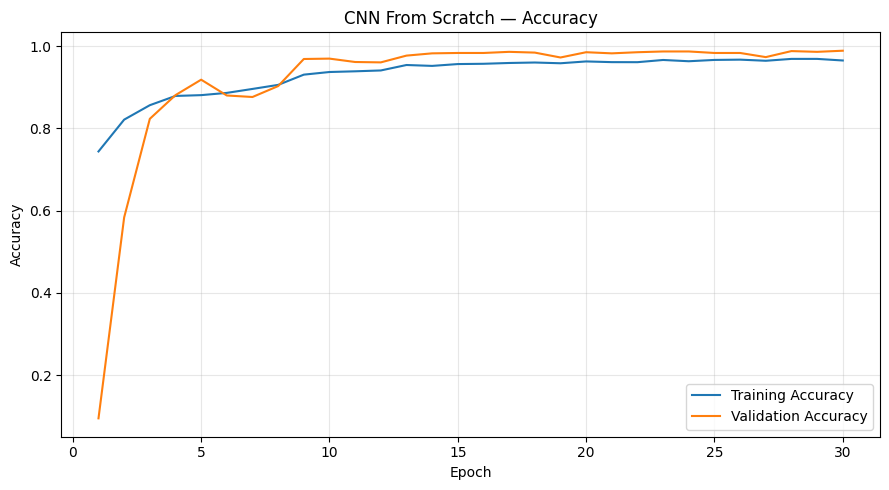

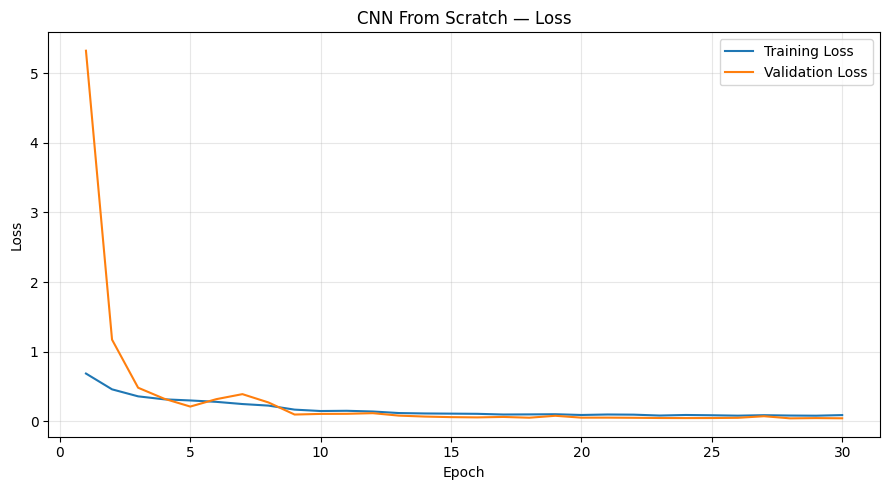

,precision,recall,f1-score,support
freshapples,0.9856,0.9856,0.9856,209.0000
freshlemons,0.9496,1.0000,0.9741,113.0000
freshoranges,0.9891,0.9945,0.9918,183.0000
rottenapples,0.9795,0.9762,0.9779,294.0000
rottenlemons,1.0000,0.9368,0.9674,95.0000
rottenoranges,0.9750,0.9750,0.9750,200.0000
accuracy,0.9799,0.9799,0.9799,0.9799
macro avg,0.9798,0.9780,0.9786,1094.0000
weighted avg,0.9802,0.9799,0.9799,1094.0000


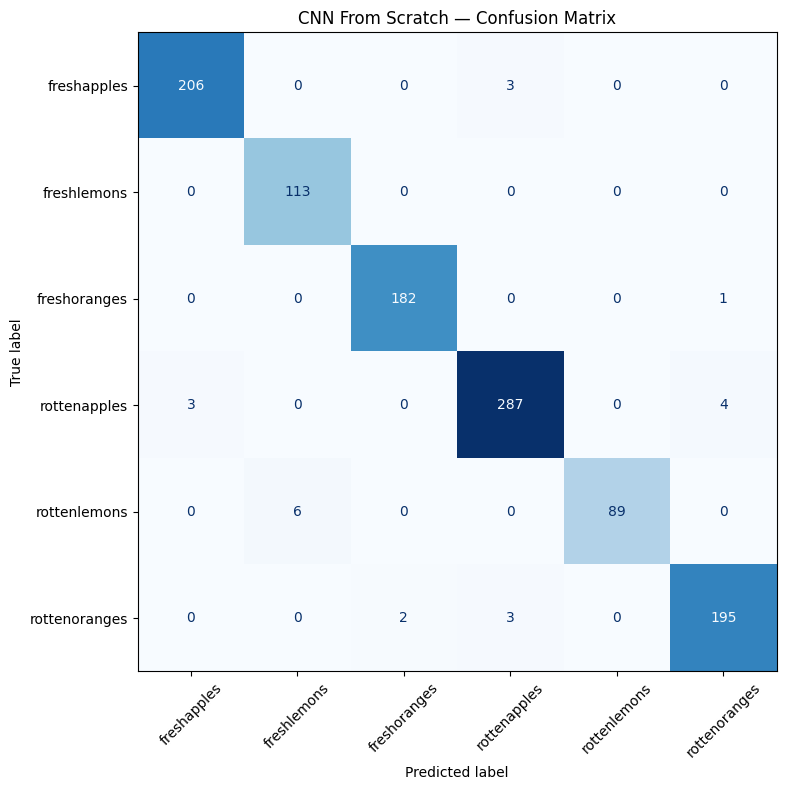

Analisis fit: GOOD FIT
Selisih performa training dan testing relatif kecil, sehingga kemampuan generalisasi model cukup baik.
✅ Target training dan testing accuracy minimal 85% tercapai.


In [20]:
scratch_result, scratch_y_true, scratch_y_pred, scratch_y_probability = evaluate_complete(
    model_scratch,
    model_name="CNN From Scratch",
    history_dict=scratch_history_all,
    prefix="cnn_scratch",
)

# Model 2 — Transfer Learning MobileNetV2

## Tahap 1: Feature Extraction

Seluruh layer MobileNetV2 dibekukan (`trainable = False`). Classification head baru terdiri dari `GlobalAveragePooling2D → Dense → Dropout → Output`.

In [21]:
# Data augmentation dibuat ulang agar tidak berbagi state model sebelumnya
tl_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomContrast(0.10),
    ],
    name="tl_data_augmentation",
)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet",
)

# Strategi wajib tahap 1: freeze seluruh convolutional base
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input_image")
x = tl_augmentation(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenet_preprocessing")(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(256, activation="relu", name="classification_dense")(x)
x = layers.BatchNormalization(name="classification_batch_norm")(x)
x = layers.Dropout(0.40, name="classification_dropout")(x)
outputs = layers.Dense(
    num_classes,
    activation="softmax",
    dtype="float32",
    name="predictions",
)(x)

model_tl = keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Base model trainable:", base_model.trainable)
print("Jumlah layer base model:", len(base_model.layers))
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model trainable: False
Jumlah layer base model: 154


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_data_augmentation            │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dense (Dense)    │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_norm       │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,486 (9.87 MB)

 Trainable params: 329,990 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [22]:
tl_stage1_callbacks, tl_stage1_checkpoint = create_callbacks(
    "mobilenetv2_feature_extraction"
)

history_tl_stage1 = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TL_STAGE1_EPOCHS,
    callbacks=tl_stage1_callbacks,
    class_weight=class_weight,
)

Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8610 - loss: 0.3739
Epoch 1: val_accuracy improved from None to 0.96798, saving model to /content/data_outputs/models/mobilenetv2_feature_extraction_best.keras

Epoch 1: finished saving model to /content/data_outputs/models/mobilenetv2_feature_extraction_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9311 - loss: 0.1850 - val_accuracy: 0.9680 - val_loss: 0.0829 - learning_rate: 0.0010
Epoch 2/30
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9694 - loss: 0.0828
Epoch 2: val_accuracy improved from 0.96798 to 0.98079, saving model to /content/data_outputs/models/mobilenetv2_feature_extraction_best.keras

Epoch 2: finished saving model to /content/data_outputs/models/mobilenetv2_feature_extraction_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.9715 - loss: 0.0817 - val_accuracy: 0.9808 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 3/30
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 78

## Tahap 2: Fine-Tuning

Sebanyak 20 layer terakhir dibuka. Layer `BatchNormalization` tetap dibekukan untuk menjaga statistik pretrained tetap stabil. Learning rate diturunkan jauh lebih kecil menjadi `1e-5`.

In [23]:
base_model.trainable = True

# Bekukan semua layer selain FINE_TUNE_LAYERS terakhir
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# BatchNormalization tetap dibekukan agar fine-tuning lebih stabil
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_base_layers = sum(layer.trainable for layer in base_model.layers)

print(f"Layer base model yang trainable: {trainable_base_layers}")
print(f"Target maksimum layer terakhir : {FINE_TUNE_LAYERS}")

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

tl_finetune_callbacks, tl_finetune_checkpoint = create_callbacks(
    "mobilenetv2_finetuned"
)

history_tl_finetune = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TL_FINETUNE_EPOCHS,
    callbacks=tl_finetune_callbacks,
    class_weight=class_weight,
)

Layer base model yang trainable: 13
Target maksimum layer terakhir : 20
Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9914 - loss: 0.0268
Epoch 1: val_accuracy improved from None to 0.99543, saving model to /content/data_outputs/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/data_outputs/models/mobilenetv2_finetuned_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9920 - loss: 0.0235 - val_accuracy: 0.9954 - val_loss: 0.0133 - learning_rate: 1.0000e-05
Epoch 2/30
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9927 - loss: 0.0198
Epoch 2: val_accuracy did not improve from 0.99543
274/274 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step - accuracy: 0.9939 - loss: 0.0183 - val_accuracy: 0.9844 - val_loss: 0.0394 - learning_rate: 1.0000e-05
Epoch 3/30
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9956 - loss: 0.0173
Epoch 3: val_accuracy did not improve from 0.99543
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step 

### Tuning Tambahan MobileNetV2

Apabila validation accuracy belum 85%, fine-tuning dilanjutkan dengan learning rate `3e-6`. Keputusan tetap hanya berdasarkan validation set, bukan testing set.

In [24]:
tl_history_before_extra = merge_histories(
    history_tl_stage1,
    history_tl_finetune,
)

extra_history_tl = None
best_tl_val = max(tl_history_before_extra.get("val_accuracy", [0]))

if AUTO_TUNE_IF_NEEDED and best_tl_val < TARGET_ACCURACY:
    print(
        f"Validation accuracy terbaik MobileNetV2 baru {best_tl_val:.2%}. "
        "Melanjutkan fine-tuning dengan learning rate 3e-6..."
    )

    model_tl.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-6),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    tl_extra_callbacks, _ = create_callbacks("mobilenetv2_extra_tuned")

    extra_history_tl = model_tl.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EXTRA_TUNING_EPOCHS,
        callbacks=tl_extra_callbacks,
        class_weight=class_weight,
    )
else:
    print(f"Validation accuracy MobileNetV2 terbaik: {best_tl_val:.2%}")

tl_history_all = merge_histories(
    history_tl_stage1,
    history_tl_finetune,
    extra_history_tl,
)

Validation accuracy MobileNetV2 terbaik: 99.54%


MobileNetV2 Transfer Learning + Fine-Tuning
Training   accuracy: 0.9950 | loss: 0.0152
Validation accuracy: 0.9954 | loss: 0.0133
Testing    accuracy: 0.9909 | loss: 0.0333


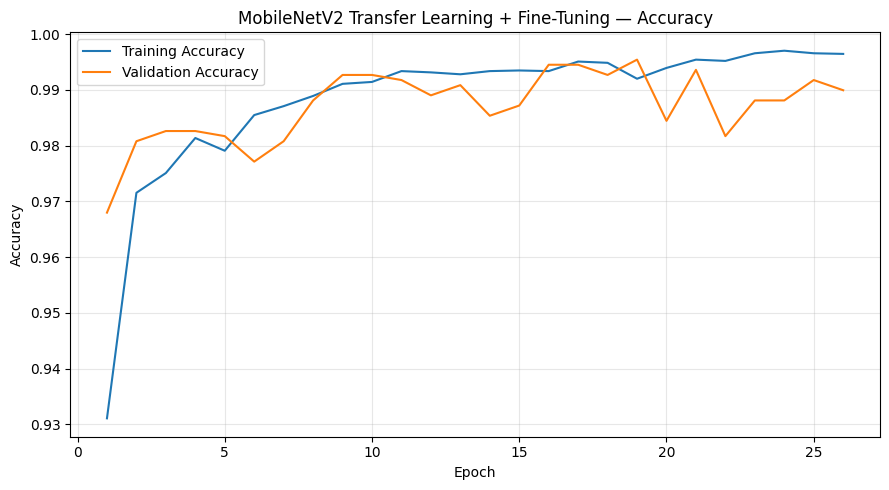

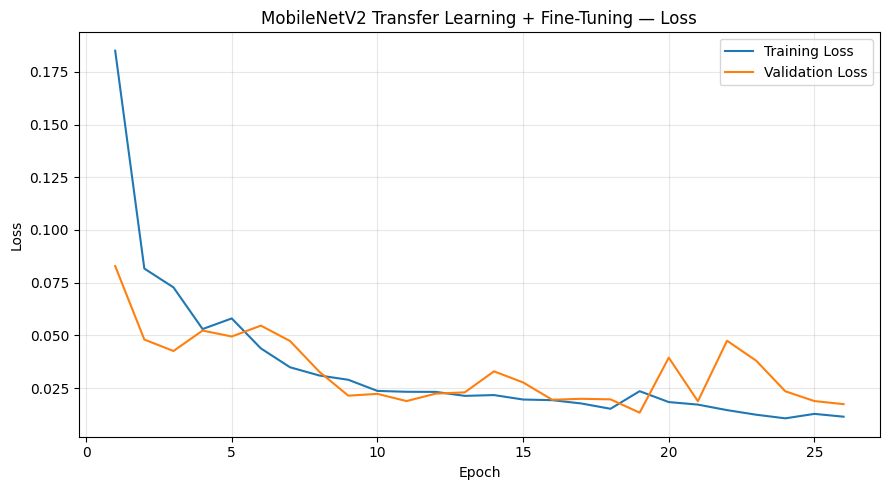

,precision,recall,f1-score,support
freshapples,0.9952,0.9856,0.9904,209.0000
freshlemons,1.0000,0.9823,0.9911,113.0000
freshoranges,0.9945,0.9836,0.9890,183.0000
rottenapples,0.9899,1.0000,0.9949,294.0000
rottenlemons,0.9694,1.0000,0.9845,95.0000
rottenoranges,0.9900,0.9900,0.9900,200.0000
accuracy,0.9909,0.9909,0.9909,0.9909
macro avg,0.9898,0.9903,0.9900,1094.0000
weighted avg,0.9910,0.9909,0.9909,1094.0000


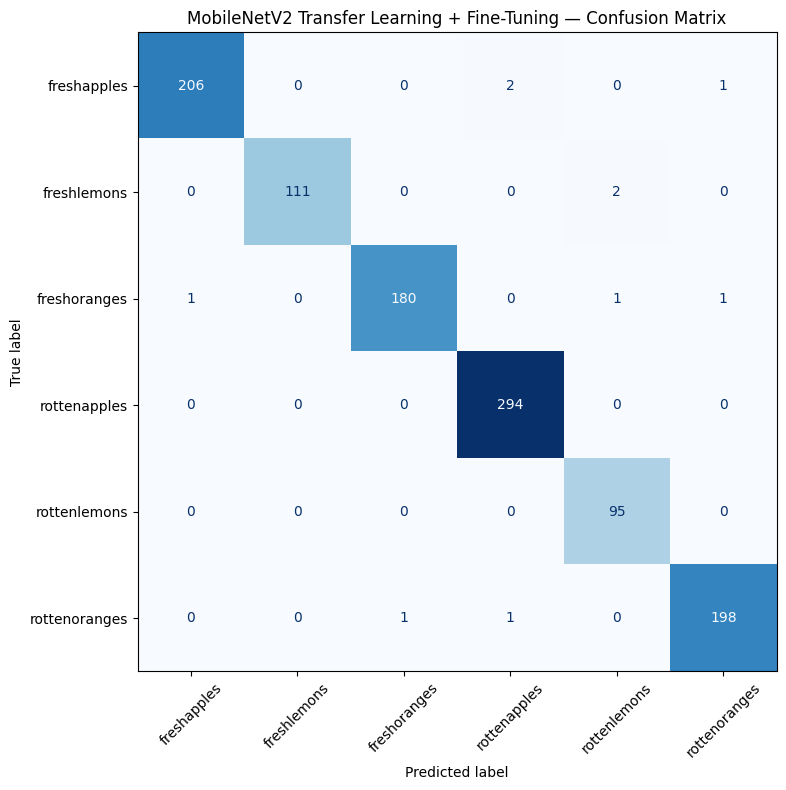

Analisis fit: GOOD FIT
Selisih performa training dan testing relatif kecil, sehingga kemampuan generalisasi model cukup baik.
✅ Target training dan testing accuracy minimal 85% tercapai.


In [25]:
tl_result, tl_y_true, tl_y_pred, tl_y_probability = evaluate_complete(
    model_tl,
    model_name="MobileNetV2 Transfer Learning + Fine-Tuning",
    history_dict=tl_history_all,
    prefix="mobilenetv2",
)

# 11. Perbandingan Kedua Model

Model terbaik dipilih berdasarkan **testing accuracy** setelah seluruh proses training selesai. Testing set hanya digunakan untuk evaluasi final dan tidak digunakan untuk tuning hyperparameter.

In [26]:
comparison_df = pd.DataFrame([scratch_result, tl_result]).set_index("model")
comparison_df = comparison_df.sort_values("test_accuracy", ascending=False)
display(comparison_df.round(4))

comparison_df.to_csv(RESULT_DIR / "model_comparison.csv")

best_model_name = comparison_df.index[0]

if best_model_name == "CNN From Scratch":
    best_model = model_scratch
    best_result = scratch_result
else:
    best_model = model_tl
    best_result = tl_result

print("Model terbaik:", best_model_name)
print(f"Testing accuracy terbaik: {best_result['test_accuracy']:.2%}")

,train_loss,train_accuracy,val_loss,val_accuracy,test_loss,test_accuracy,fit_status
model,,,,,,,
MobileNetV2 Transfer Learning + Fine-Tuning,0.0152,0.9950,0.0133,0.9954,0.0333,0.9909,GOOD FIT
CNN From Scratch,0.0493,0.9863,0.0439,0.9881,0.0557,0.9799,GOOD FIT


Model terbaik: MobileNetV2 Transfer Learning + Fine-Tuning
Testing accuracy terbaik: 99.09%


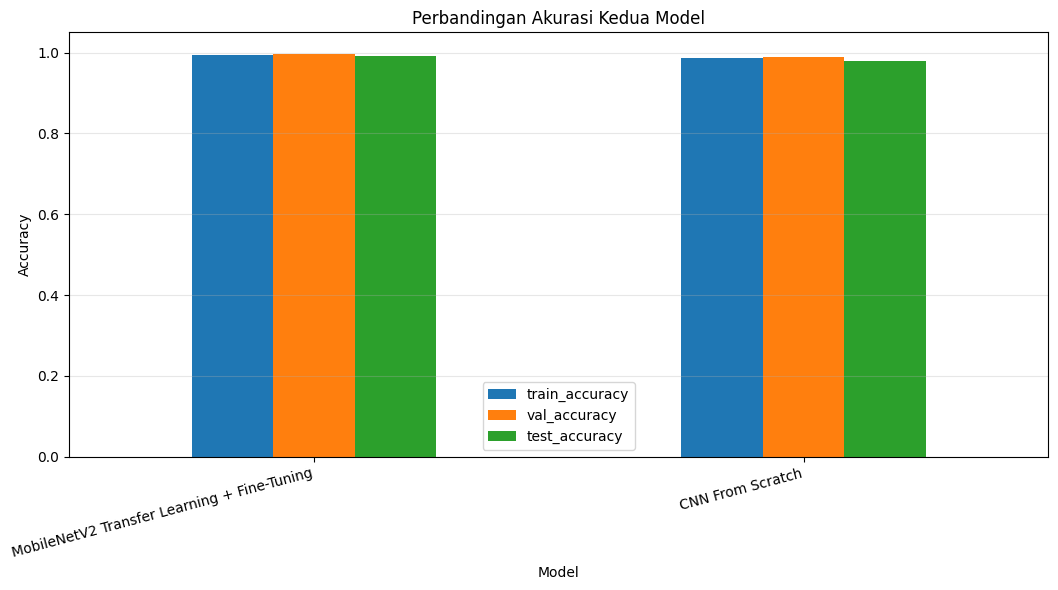

In [27]:
# Visualisasi perbandingan akurasi
accuracy_comparison = comparison_df[
    ["train_accuracy", "val_accuracy", "test_accuracy"]
]

ax = accuracy_comparison.plot(kind="bar", figsize=(11, 6))
plt.title("Perbandingan Akurasi Kedua Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "perbandingan_akurasi_model.png", dpi=150)
plt.show()

# 12. Penyimpanan Model dalam Tiga Format

Model terbaik diekspor sebagai:

1. **TensorFlow SavedModel** untuk backend/cloud.
2. **TensorFlow Lite (`.tflite`)** untuk mobile atau embedded system.
3. **TensorFlow.js** untuk aplikasi berbasis browser.

Selain tiga format wajib, file `.keras`, `.h5`, daftar kelas JSON, dan ringkasan hasil juga disimpan untuk dokumentasi.

In [28]:
# Simpan model native Keras sebagai cadangan
KERAS_PATH = EXPORT_DIR / "best_datatrash_model.keras"
H5_PATH    = EXPORT_DIR / "best_datatrash_model.h5"

best_model.save(KERAS_PATH)
best_model.save(H5_PATH, include_optimizer=False)

with open(EXPORT_DIR / "class_names.json", "w", encoding="utf-8") as file:
    json.dump(class_names, file, ensure_ascii=False, indent=2)

with open(EXPORT_DIR / "best_model_info.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "best_model": best_model_name,
            "image_size": [IMG_HEIGHT, IMG_WIDTH],
            "num_classes": num_classes,
            "class_names": class_names,
            "metrics": {
                key: (float(value) if isinstance(value, (np.floating, float)) else value)
                for key, value in best_result.items()
                if key != "model"
            },
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Keras model:", KERAS_PATH)
print("H5 model   :", H5_PATH)

Keras model: /content/data_outputs/exports/best_datatrash_model.keras
H5 model   : /content/data_outputs/exports/best_datatrash_model.h5


In [29]:
# 1) TensorFlow SavedModel
SAVEDMODEL_DIR = EXPORT_DIR / "saved_model"

if SAVEDMODEL_DIR.exists():
    shutil.rmtree(SAVEDMODEL_DIR)

try:
    # Keras 3
    best_model.export(str(SAVEDMODEL_DIR), format="tf_saved_model")
except (AttributeError, TypeError):
    # Fallback untuk versi TensorFlow/Keras lain
    tf.saved_model.save(best_model, str(SAVEDMODEL_DIR))

print("✅ SavedModel tersimpan di:", SAVEDMODEL_DIR)

Saved artifact at '/content/data_outputs/exports/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138646711983696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711986960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711989648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711988688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711991184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711981392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711984272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711985808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711986576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138646711989456: TensorSpec(shape=(), dtype=tf.resource, nam

In [30]:
import tensorflow as tf
from tensorflow import keras
import shutil
from pathlib import Path

# Pastikan variabel ini sudah tersedia
print("Image size   :", IMG_HEIGHT, IMG_WIDTH)
print("Jumlah kelas :", num_classes)

# Input baru khusus deployment
export_inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    dtype=tf.float32,
    name="input_image"
)

# Tidak memasukkan tl_augmentation
x = tf.keras.applications.mobilenet_v2.preprocess_input(export_inputs)

# Gunakan MobileNetV2 yang sudah dilatih/fine-tuning
x = base_model(x, training=False)

# Gunakan kembali classification head beserta bobot hasil training
x = model_tl.get_layer("global_average_pooling")(x)
x = model_tl.get_layer("classification_dense")(x)

x = model_tl.get_layer("classification_batch_norm")(
    x,
    training=False
)

x = model_tl.get_layer("classification_dropout")(
    x,
    training=False
)

export_outputs = model_tl.get_layer("predictions")(x)

# Model deployment tanpa augmentasi
inference_model = keras.Model(
    inputs=export_inputs,
    outputs=export_outputs,
    name="mobilenetv2_datatrash_inference"
)

inference_model.summary()

Image size   : 224 224
Jumlah kelas : 6


Model: "mobilenetv2_datatrash_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dense (Dense)    │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_norm       │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,486 (9.87 MB)

 Trainable params: 1,524,870 (5.82 MB)

 Non-trainable params: 1,063,616 (4.06 MB)

In [31]:
sample_images, sample_labels = next(iter(test_ds))

sample_batch = sample_images[:5]

original_predictions = model_tl(
    sample_batch,
    training=False
).numpy()

inference_predictions = inference_model(
    sample_batch,
    training=False
).numpy()

maximum_difference = np.max(
    np.abs(original_predictions - inference_predictions)
)

print("Selisih maksimum prediksi:", maximum_difference)

print(
    "Prediksi model asli     :",
    np.argmax(original_predictions, axis=1)
)

print(
    "Prediksi inference model:",
    np.argmax(inference_predictions, axis=1)
)

Selisih maksimum prediksi: 3.6379788e-10
Prediksi model asli     : [0 2 3 3 2]
Prediksi inference model: [0 2 3 3 2]


In [32]:
CLEAN_SAVEDMODEL_DIR = EXPORT_DIR / "saved_model_inference"

if CLEAN_SAVEDMODEL_DIR.exists():
    shutil.rmtree(CLEAN_SAVEDMODEL_DIR)


@tf.function(
    input_signature=[
        tf.TensorSpec(
            shape=[None, IMG_HEIGHT, IMG_WIDTH, 3],
            dtype=tf.float32,
            name="input_image"
        )
    ]
)
def serving_function(input_image):
    probabilities = inference_model(
        input_image,
        training=False
    )

    return {
        "probabilities": probabilities
    }


tf.saved_model.save(
    inference_model,
    str(CLEAN_SAVEDMODEL_DIR),
    signatures={
        "serving_default": serving_function
    }
)

print("✅ Clean SavedModel tersimpan di:")
print(CLEAN_SAVEDMODEL_DIR)

✅ Clean SavedModel tersimpan di:
/content/data_outputs/exports/saved_model_inference


In [33]:
TFLITE_PATH = EXPORT_DIR / "best_data_model.tflite"

converter = tf.lite.TFLiteConverter.from_saved_model(
    str(CLEAN_SAVEDMODEL_DIR)
)

# Dynamic range optimization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

# Hanya izinkan operasi TFLite native
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

try:
    tflite_model = converter.convert()

except Exception as error:
    print("Konversi teroptimasi gagal:")
    print(error)
    print("\nMencoba konversi Float32 standar...")

    converter = tf.lite.TFLiteConverter.from_saved_model(
        str(CLEAN_SAVEDMODEL_DIR)
    )

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS
    ]

    tflite_model = converter.convert()


TFLITE_PATH.write_bytes(tflite_model)

print("✅ TFLite berhasil disimpan:")
print(TFLITE_PATH)

print(
    f"Ukuran TFLite: "
    f"{TFLITE_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

✅ TFLite berhasil disimpan:
/content/data_outputs/exports/best_data_model.tflite
Ukuran TFLite: 0.21 MB


In [34]:
interpreter = tf.lite.Interpreter(
    model_path=str(TFLITE_PATH)
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input TFLite:")
print(input_details)

print("\nOutput TFLite:")
print(output_details)

Input TFLite:
[{'name': 'serving_default_input_image:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output TFLite:
[{'name': 'StatefulPartitionedCall:0', 'index': 1054, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [35]:
# Ambil satu gambar testing
sample_images, sample_labels = next(iter(test_ds))

test_image = sample_images[:1].numpy().astype(
    input_details[0]["dtype"]
)

# Prediksi Keras
keras_prediction = inference_model.predict(
    test_image,
    verbose=0
)

# Prediksi TFLite
interpreter.set_tensor(
    input_details[0]["index"],
    test_image
)

interpreter.invoke()

tflite_prediction = interpreter.get_tensor(
    output_details[0]["index"]
)

keras_class = int(np.argmax(keras_prediction[0]))
tflite_class = int(np.argmax(tflite_prediction[0]))

print("Label asli:")
print(class_names[int(sample_labels[0])])

print("\nPrediksi Keras:")
print(class_names[keras_class])
print("Probabilitas:", float(np.max(keras_prediction[0])))

print("\nPrediksi TFLite:")
print(class_names[tflite_class])
print("Probabilitas:", float(np.max(tflite_prediction[0])))

Label asli:
freshapples

Prediksi Keras:
freshapples
Probabilitas: 0.9999173879623413

Prediksi TFLite:
freshapples
Probabilitas: nan


### Ekspor TensorFlow.js

Paket TensorFlow.js dipasang **setelah training selesai**. Hal ini mengurangi risiko perubahan dependency selama pelatihan.

In [36]:
!pip install -q tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.1

In [37]:
import shutil
import subprocess
import sys
import os
from pathlib import Path

# Model ini harus model tanpa tl_augmentation
# inference_model dibuat pada bagian perbaikan TFLite sebelumnya

TFJS_H5_PATH = EXPORT_DIR / "data_inference_model.h5"

inference_model.save(
    str(TFJS_H5_PATH),
    include_optimizer=False
)

print("✅ Model inference H5 tersimpan:")
print(TFJS_H5_PATH)

✅ Model inference H5 tersimpan:
/content/data_outputs/exports/data_inference_model.h5


In [38]:
# 3) TensorFlow.js dari clean inference model

TFJS_DIR = EXPORT_DIR / "tfjs_model"

if TFJS_DIR.exists():
    shutil.rmtree(TFJS_DIR)

TFJS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

converter_executable = shutil.which(
    "tensorflowjs_converter"
)

if converter_executable is None:
    command = [
        sys.executable,
        "-m",
        "tensorflowjs.converters.converter",
        "--input_format=keras",
        "--output_format=tfjs_layers_model",
        str(TFJS_H5_PATH),
        str(TFJS_DIR),
    ]
else:
    command = [
        converter_executable,
        "--input_format=keras",
        "--output_format=tfjs_layers_model",
        str(TFJS_H5_PATH),
        str(TFJS_DIR),
    ]

print("Menjalankan:")
print(" ".join(command))

# Converter tidak membutuhkan GPU.
# Ini juga mengurangi pesan CUDA/cuDNN yang tidak diperlukan.
converter_environment = os.environ.copy()
converter_environment["CUDA_VISIBLE_DEVICES"] = "-1"
converter_environment["TF_CPP_MIN_LOG_LEVEL"] = "2"

result = subprocess.run(
    command,
    capture_output=True,
    text=True,
    env=converter_environment,
)

if result.stdout.strip():
    print("\nOUTPUT:")
    print(result.stdout)

if result.returncode != 0:
    print("\nERROR:")
    print(result.stderr)

    raise RuntimeError(
        "Konversi TensorFlow.js gagal. "
        "Pastikan TFJS_H5_PATH berasal dari inference_model "
        "yang tidak mengandung data augmentation."
    )

model_json = TFJS_DIR / "model.json"

if not model_json.exists():
    raise FileNotFoundError(
        "Konversi selesai, tetapi model.json tidak ditemukan."
    )

tfjs_files = sorted(
    file.name
    for file in TFJS_DIR.iterdir()
)

print("\n✅ TensorFlow.js berhasil disimpan:")
print(TFJS_DIR)

print("\nIsi folder TFJS:")
for filename in tfjs_files:
    print(" -", filename)

Menjalankan:
/usr/local/bin/tensorflowjs_converter --input_format=keras --output_format=tfjs_layers_model /content/data_outputs/exports/data_inference_model.h5 /content/data_outputs/exports/tfjs_model

OUTPUT:
failed to lookup keras version from the file,
    this is likely a weight only file


✅ TensorFlow.js berhasil disimpan:
/content/data_outputs/exports/tfjs_model

Isi folder TFJS:
 - group1-shard1of3.bin
 - group1-shard2of3.bin
 - group1-shard3of3.bin
 - model.json


In [39]:
import json

with open(
    TFJS_DIR / "model.json",
    "r",
    encoding="utf-8"
) as file:
    tfjs_metadata = json.load(file)

print("Format model:")
print(tfjs_metadata.get("format"))

print("\nGenerated by:")
print(tfjs_metadata.get("generatedBy"))

print("\nConverted by:")
print(tfjs_metadata.get("convertedBy"))

print("\nJumlah weight manifest:")
print(len(tfjs_metadata.get("weightsManifest", [])))

Format model:
layers-model

Generated by:
keras v3.13.2

Converted by:
TensorFlow.js Converter v4.22.0

Jumlah weight manifest:
1


# 13. Inferensi Menggunakan TensorFlow Lite

Beberapa gambar diambil dari **testing set**. Gambar tersebut tidak pernah digunakan untuk update bobot selama training, sehingga dapat dipakai sebagai data baru/tidak terlihat oleh model selama proses belajar.

In [40]:
# Inisialisasi TFLite Interpreter
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details :", input_details)
print("Output details:", output_details)

Input details : [{'name': 'serving_default_input_image:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 1054, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [41]:
def prepare_tflite_input(image_path, input_detail):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize((IMG_WIDTH, IMG_HEIGHT))
        image_array = np.asarray(image, dtype=np.float32)

    image_array = np.expand_dims(image_array, axis=0)
    input_dtype = input_detail["dtype"]

    if input_dtype in (np.uint8, np.int8):
        scale, zero_point = input_detail["quantization"]
        if scale == 0:
            raise ValueError("Skala kuantisasi input bernilai 0.")
        image_array = image_array / scale + zero_point
        image_array = np.clip(
            image_array,
            np.iinfo(input_dtype).min,
            np.iinfo(input_dtype).max,
        ).astype(input_dtype)
    else:
        image_array = image_array.astype(input_dtype)

    return image_array

def predict_tflite(image_path):
    input_tensor = prepare_tflite_input(image_path, input_details[0])

    interpreter.set_tensor(input_details[0]["index"], input_tensor)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])[0]

    if output_details[0]["dtype"] in (np.uint8, np.int8):
        scale, zero_point = output_details[0]["quantization"]
        output = (output.astype(np.float32) - zero_point) * scale

    predicted_index = int(np.argmax(output))
    probability = float(output[predicted_index])

    return predicted_index, probability, output

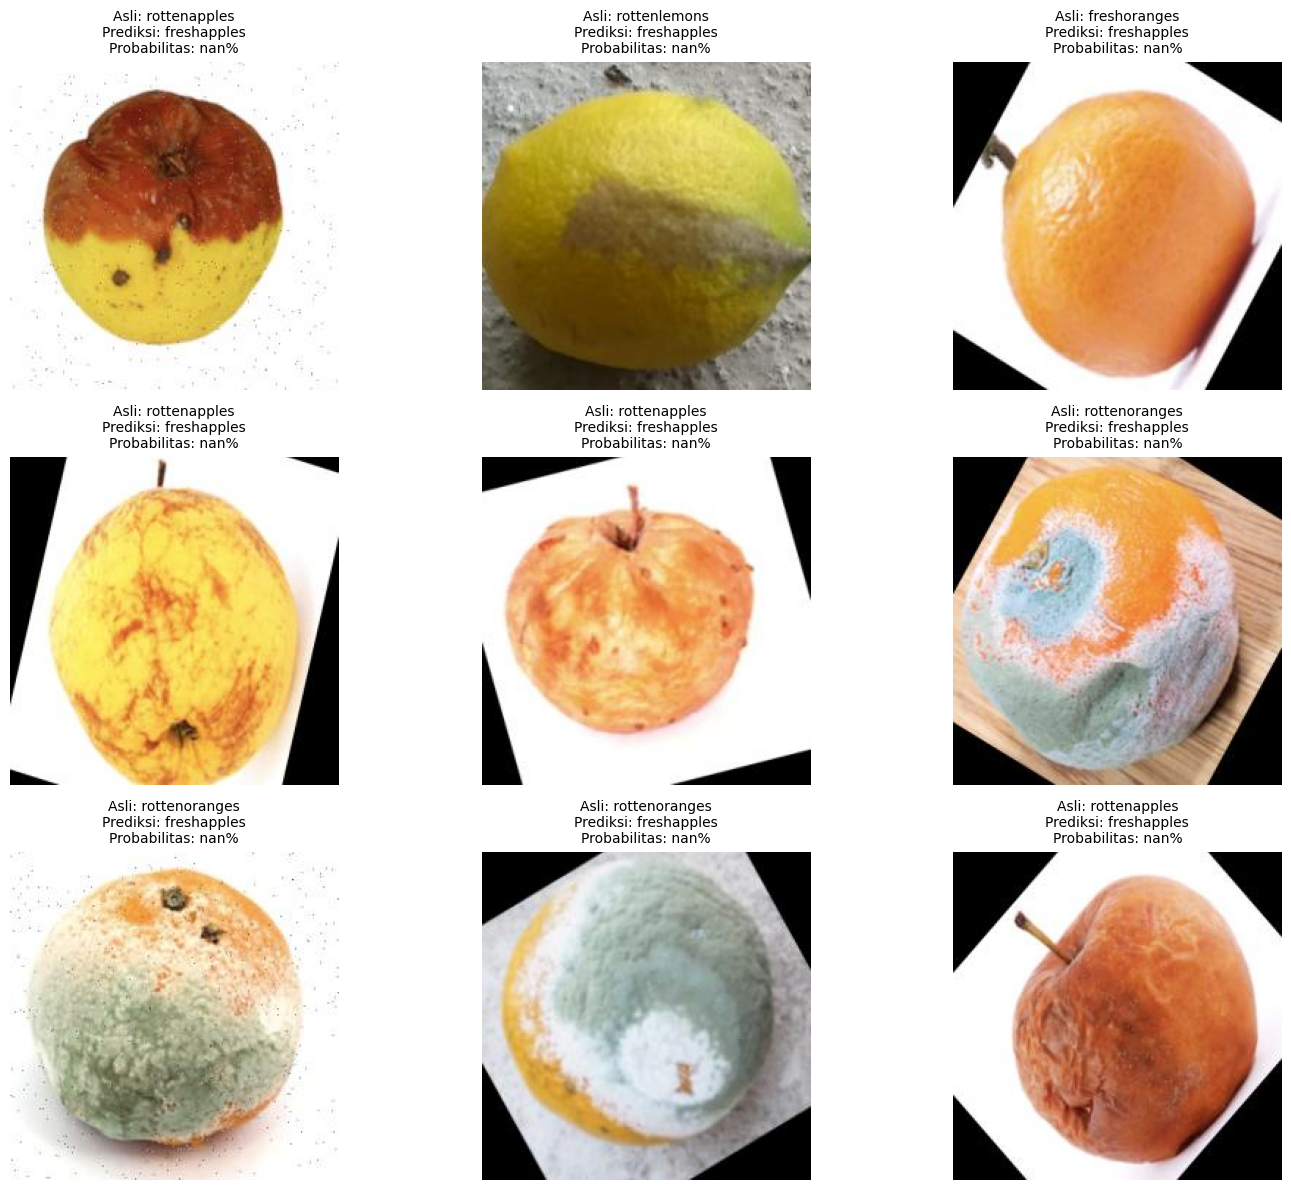

,filepath,label_asli,hasil_prediksi,probabilitas,benar
0,/content/DATA_SET_A_O_L-1/train/rottenapples/s...,rottenapples,freshapples,NaN,False
1,/content/DATA_SET_A_O_L-1/train/rottenlemons/b...,rottenlemons,freshapples,NaN,False
2,/content/DATA_SET_A_O_L-1/train/freshoranges/r...,freshoranges,freshapples,NaN,False
3,/content/DATA_SET_A_O_L-1/train/rottenapples/r...,rottenapples,freshapples,NaN,False
4,/content/DATA_SET_A_O_L-1/train/rottenapples/r...,rottenapples,freshapples,NaN,False
5,/content/DATA_SET_A_O_L-1/train/rottenoranges/...,rottenoranges,freshapples,NaN,False
6,/content/DATA_SET_A_O_L-1/train/rottenoranges/...,rottenoranges,freshapples,NaN,False
7,/content/DATA_SET_A_O_L-1/test/rottenoranges/r...,rottenoranges,freshapples,NaN,False
8,/content/DATA_SET_A_O_L-1/train/rottenapples/r...,rottenapples,freshapples,NaN,False


In [42]:
# Ambil beberapa contoh acak dari testing set
NUM_INFERENCE_SAMPLES = min(9, len(test_df))
inference_samples = test_df.sample(
    n=NUM_INFERENCE_SAMPLES,
    random_state=SEED,
).reset_index(drop=True)

inference_records = []

plt.figure(figsize=(15, 12))

for index, row in inference_samples.iterrows():
    predicted_index, probability, probabilities = predict_tflite(row["filepath"])
    predicted_label = class_names[predicted_index]
    actual_label = row["label"]
    is_correct = predicted_label == actual_label

    inference_records.append({
        "filepath": row["filepath"],
        "label_asli": actual_label,
        "hasil_prediksi": predicted_label,
        "probabilitas": probability,
        "benar": is_correct,
    })

    with Image.open(row["filepath"]) as image:
        image = image.convert("RGB")
        plt.subplot(3, 3, index + 1)
        plt.imshow(image)
        plt.title(
            f"Asli: {actual_label}\n"
            f"Prediksi: {predicted_label}\n"
            f"Probabilitas: {probability:.2%}",
            fontsize=10,
        )
        plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULT_DIR / "tflite_inference_samples.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

inference_df = pd.DataFrame(inference_records)
display(inference_df)
inference_df.to_csv(RESULT_DIR / "tflite_inference_results.csv", index=False)

## 14. Inferensi Opsional dengan Gambar Eksternal

Unggah beberapa gambar yang benar-benar berasal dari luar dataset. Karena notebook tidak mengetahui label aslinya secara otomatis, isi `true_labels` sesuai nama file setelah upload.

In [43]:
# Jalankan sel ini hanya jika ingin menguji gambar eksternal.
#
# from google.colab import files
# uploaded = files.upload()
#
# Contoh:
# true_labels = {
#     "contoh_1.jpg": "plastic",
#     "contoh_2.jpg": "paper",
# }
#
# external_results = []
#
# for filename in uploaded.keys():
#     predicted_index, probability, _ = predict_tflite(filename)
#     predicted_label = class_names[predicted_index]
#     actual_label = true_labels.get(filename, "BELUM DIISI")
#
#     external_results.append({
#         "filename": filename,
#         "label_asli": actual_label,
#         "hasil_prediksi": predicted_label,
#         "probabilitas": probability,
#     })
#
#     with Image.open(filename) as image:
#         plt.figure(figsize=(5, 5))
#         plt.imshow(image.convert("RGB"))
#         plt.title(
#             f"Asli: {actual_label}\n"
#             f"Prediksi: {predicted_label}\n"
#             f"Probabilitas: {probability:.2%}"
#         )
#         plt.axis("off")
#         plt.show()
#
# display(pd.DataFrame(external_results))

# 15. Ringkasan Analisis Otomatis

Sel berikut menghasilkan paragraf ringkas yang dapat digunakan sebagai dasar pembahasan hasil. Tetap sesuaikan dengan grafik dan confusion matrix yang diperoleh saat notebook dijalankan.

In [44]:
scratch_acc = scratch_result["test_accuracy"]
tl_acc = tl_result["test_accuracy"]

if scratch_acc > tl_acc:
    comparison_statement = (
        f"CNN From Scratch menghasilkan testing accuracy lebih tinggi "
        f"({scratch_acc:.2%}) dibandingkan MobileNetV2 ({tl_acc:.2%})."
    )
elif tl_acc > scratch_acc:
    comparison_statement = (
        f"MobileNetV2 menghasilkan testing accuracy lebih tinggi "
        f"({tl_acc:.2%}) dibandingkan CNN From Scratch ({scratch_acc:.2%})."
    )
else:
    comparison_statement = (
        f"Kedua model menghasilkan testing accuracy yang sama, yaitu "
        f"{scratch_acc:.2%}."
    )

analysis_text = f'''
Hasil eksperimen menunjukkan bahwa CNN From Scratch memperoleh training accuracy
{scratch_result["train_accuracy"]:.2%}, validation accuracy
{scratch_result["val_accuracy"]:.2%}, dan testing accuracy
{scratch_result["test_accuracy"]:.2%}. Model ini dikategorikan sebagai
{scratch_result["fit_status"]}.

MobileNetV2 dengan feature extraction dan fine-tuning memperoleh training accuracy
{tl_result["train_accuracy"]:.2%}, validation accuracy
{tl_result["val_accuracy"]:.2%}, dan testing accuracy
{tl_result["test_accuracy"]:.2%}. Model ini dikategorikan sebagai
{tl_result["fit_status"]}.

{comparison_statement} Model terbaik berdasarkan testing accuracy adalah
{best_model_name}. Confusion matrix dan classification report perlu digunakan
untuk mengidentifikasi kelas yang paling mudah dan paling sulit dikenali serta
untuk menilai precision, recall, dan F1-score setiap kelas.
'''.strip()

print(analysis_text)

with open(RESULT_DIR / "ringkasan_analisis.txt", "w", encoding="utf-8") as file:
    file.write(analysis_text)

Hasil eksperimen menunjukkan bahwa CNN From Scratch memperoleh training accuracy
98.63%, validation accuracy
98.81%, dan testing accuracy
97.99%. Model ini dikategorikan sebagai
GOOD FIT.

MobileNetV2 dengan feature extraction dan fine-tuning memperoleh training accuracy
99.50%, validation accuracy
99.54%, dan testing accuracy
99.09%. Model ini dikategorikan sebagai
GOOD FIT.

MobileNetV2 menghasilkan testing accuracy lebih tinggi (99.09%) dibandingkan CNN From Scratch (97.99%). Model terbaik berdasarkan testing accuracy adalah
MobileNetV2 Transfer Learning + Fine-Tuning. Confusion matrix dan classification report perlu digunakan
untuk mengidentifikasi kelas yang paling mudah dan paling sulit dikenali serta
untuk menilai precision, recall, dan F1-score setiap kelas.


# 16. Validasi File Ekspor dan Pembuatan ZIP

In [45]:
required_exports = {
    "SavedModel": SAVEDMODEL_DIR / "saved_model.pb",
    "TensorFlow Lite": TFLITE_PATH,
    "TensorFlow.js": TFJS_DIR / "model.json",
    "Keras": KERAS_PATH,
    "Class names": EXPORT_DIR / "class_names.json",
}

validation_records = []

for export_name, export_path in required_exports.items():
    exists = export_path.exists()
    validation_records.append({
        "format": export_name,
        "path": str(export_path),
        "tersedia": exists,
    })
    print(("✅" if exists else "❌"), export_name, "->", export_path)

export_validation_df = pd.DataFrame(validation_records)
display(export_validation_df)

if not export_validation_df["tersedia"].all():
    raise FileNotFoundError(
        "Ada format ekspor yang belum berhasil dibuat. "
        "Periksa output sel ekspor terkait."
    )

ZIP_BASE = Path("/content/datafluits_submission")
ZIP_PATH = Path(shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=str(OUTPUT_DIR),
))

print("✅ Semua output dikompres:")
print(ZIP_PATH)
print(f"Ukuran ZIP: {ZIP_PATH.stat().st_size / (1024**2):.2f} MB")

✅ SavedModel -> /content/data_outputs/exports/saved_model/saved_model.pb
✅ TensorFlow Lite -> /content/data_outputs/exports/best_data_model.tflite
✅ TensorFlow.js -> /content/data_outputs/exports/tfjs_model/model.json
✅ Keras -> /content/data_outputs/exports/best_datatrash_model.keras
✅ Class names -> /content/data_outputs/exports/class_names.json


,format,path,tersedia
0,SavedModel,/content/data_outputs/exports/saved_model/save...,True
1,TensorFlow Lite,/content/data_outputs/exports/best_data_model....,True
2,TensorFlow.js,/content/data_outputs/exports/tfjs_model/model...,True
3,Keras,/content/data_outputs/exports/best_datatrash_m...,True
4,Class names,/content/data_outputs/exports/class_names.json,True


✅ Semua output dikompres:
/content/datafluits_submission.zip
Ukuran ZIP: 123.46 MB


In [46]:
# Download hasil ke komputer
from google.colab import files

files.download(str(ZIP_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kesimpulan

Notebook telah mencakup dua pendekatan model, callback, grafik akurasi dan loss, confusion matrix, classification report, analisis overfitting/underfitting/good fit, ekspor tiga format, serta inferensi menggunakan TensorFlow Lite.

### Catatan agar target 85% lebih mudah tercapai

- Pastikan dataset benar-benar memiliki minimal 8.000 gambar dan minimal 4 kelas.
- Periksa ketidakseimbangan kelas serta kualitas label.
- Jalankan dengan GPU.
- Naikkan `SCRATCH_EPOCHS`, `TL_STAGE1_EPOCHS`, atau `TL_FINETUNE_EPOCHS` jika kurva validasi masih membaik.
- Kurangi augmentasi apabila objek menjadi terlalu sulit dikenali.
- Tambah `FINE_TUNE_LAYERS` secara bertahap, misalnya dari 20 menjadi 30.
- Jangan melakukan tuning berdasarkan testing set untuk menghindari data leakage.